# OrchardQuant-3D — pear-orchard tree segmentation and canopy traits (minimal reproduction)

**Paper:** Xia Y., Li H., Sun G., Zhou J. *OrchardQuant-3D: combining drone and LiDAR to perform scalable 3D phenotyping for characterising key canopy and floral traits in fruit orchards.* Plant Biotechnology Journal 23(11):4910–4929 (2025). DOI: [10.1111/pbi.70229](https://doi.org/10.1111/pbi.70229) — PMC12576445 (CC BY).

**Code:** [The-Zhou-Lab/OrchardQuant-3D](https://github.com/The-Zhou-Lab/OrchardQuant-3D), release V1.2, BSD-3-Clause.

**ADAPTED SCOPE — partial demonstration, executed.** All scientific functions are copied **verbatim** from the authors' release (`gui_file/part1.py`, `gui_file/part2.py`, `jupyter notebook/Part3` and `Part6`); what is adapted is the *extent of the data processed*: the released `dormancy_pear.las` orchard cloud is 4.5 GB (~10⁸ points), too large for a free Colab VM, so this notebook deterministically selects a contiguous **sub-orchard patch** (an affine sub-window of the RTK orchard corners) and runs the *full* authors' pipeline on it: ROI clipping → SOR denoising → CSF ground filtering → CHM generation → RTK CHM registration → automatic tree detection → single-tree clipping → per-tree denoising → SLBC 3D skeletonization → tree-level canopy traits. **適応範囲(日本語):** 著者の関数をそのまま使用し、処理範囲だけを4.5GBの果樹園点群の一部領域(サブ区画)に限定しています。手法の連結・パラメータは元のままです。

**Not reproduced here (out of scope):** UAV/lidar fusion and grid renaming, branch-level traits, floral traits, the apple-orchard Stratified Transformer fruit detection (no confirmed trained weights in release V1.2), and full-orchard trait benchmarking. A patch-level run does not verify the paper's dataset-level accuracy.

**Runtime:** CPU only — no GPU is used anywhere in this pipeline.

## Runtime selection — CPU

Select **Runtime → Change runtime type → CPU** in Colab, then *Run all*.

Expected duration ≈ 25–45 min, dominated by the 1.45 GB `Data_pear.zip` download, WhiteboxTools processing and SLBC skeletonization. Disk use ≈ 8 GB (the zip, the extracted 4.5 GB dormancy cloud and intermediate files).

**ランタイム(日本語):** GPU不要。「ランタイム → CPU」を選んで「すべてのセルを実行」してください。所要目安は25〜45分、ディスク約8GBです。

### Install dependencies

Installs the author-required libraries. Two recorded substitutions (both third-party dependencies, not author code):
- `pc-skeletor` is installed with `--no-deps` plus only the modules its SLBC code path imports (verified in `pc_skeletor/laplacian.py` v1.0.0); the omitted default extras (torch, dgl) are unused and very large.
- `whitebox==2.3.6` replaces the author-cited 2.3.1 (same API; 2.3.1 fails to unpack the current WhiteboxTools binary zip on Colab). `mistree==2.0.0` replaces the author-cited `mistree==1.2.0`: the 1.2.0 sdist builds with `numpy.distutils` and fails on Python 3.13; 2.0.0 is a pure-Python wheel with the same `GetMST(x, y, z)` / `get_stats(include_index, k_neighbours)` API used by pc-skeletor.
`CSF` ground filtering uses `cloth_simulation_filter` (the official jianboqi/CSF binding providing the `CSF` module; the PyPI name `CSF` is an unrelated package), built from its sdist. `whitebox` uses 2.3.6 (the author-cited 2.3.1 cannot unpack the current WhiteboxTools binary zip layout on Colab; the tool API is unchanged) and downloads the WhiteboxTools binary on first use.

**依存関係(日本語):** 論文指定ライブラリを導入します。mistreeはpy3.13でビルドできない1.2.0の代わりに同APIの2.0.0を使用します。

In [ ]:
%%time
%pip install -q laspy==2.5.1 whitebox==2.3.6 pyshp==2.3.1 vtk
%pip install -q pc-skeletor==1.0.0 --no-deps
%pip install -q open3d robust-laplacian networkx imageio wget tqdm
%pip install -q mistree==2.0.0
%pip install -q cloth_simulation_filter

     ━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/1.6 MB 3.6 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.8 MB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


...

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 948.6 kB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


CPU times: user 9.16 s, sys: 1.79 s, total: 10.9 s
Wall time: 6min 5s


### Download the authors' pear test data and RTK shapefiles

Downloads release-V1.2 asset `Data_pear.zip` (1,455,045,764 bytes; contains `dormancy_pear.las` 4.50 GB and `flowering_pear.las` 1.08 GB) and `RTK_shapefiles.zip` (RTK ROI corner points) from the pinned GitHub release, verifies sizes and SHA-256, then **selectively extracts** only `dormancy_pear.las` and the RTK shapefiles — the flowering cloud belongs to the out-of-scope floral branch. Dataset bytes are handled only inside this Colab VM.

**データ入手(日本語):** V1.2リリースの`Data_pear.zip`と`RTK_shapefiles.zip`をダウンロードしてSHA-256を検証し、休眠期の点群とRTKシェープファイルのみ展開します。

In [ ]:
%%time
import hashlib, urllib.request, os, zipfile

BASE = "https://github.com/The-Zhou-Lab/OrchardQuant-3D/releases/download/V1.2"
os.makedirs("/content/oq3d", exist_ok=True)

for name in ("Data_pear.zip", "RTK_shapefiles.zip"):
    dest = f"/content/oq3d/{name}"
    if not os.path.exists(dest):
        print(f"downloading {name} ...", flush=True)
        urllib.request.urlretrieve(f"{BASE}/{name}", dest)
    size = os.path.getsize(dest)
    h = hashlib.sha256()
    with open(dest, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    print(f"{name}: {size:,} bytes  sha256={h.hexdigest()}")

assert os.path.getsize("/content/oq3d/Data_pear.zip") > 1_000_000_000, "Data_pear.zip unexpectedly small - aborting"
with zipfile.ZipFile("/content/oq3d/RTK_shapefiles.zip") as z:
    z.extractall("/content/oq3d/")
with zipfile.ZipFile("/content/oq3d/Data_pear.zip") as z:
    z.extract("Data_pear/dormancy_pear.las", "/content/oq3d/")
    print("extracted:", [i.filename for i in z.infolist() if i.filename.endswith('.las')])

downloading Data_pear.zip ...


Data_pear.zip: 1,455,045,764 bytes  sha256=355c10641abafdc6d9640601d5a22d7476c6d4b490b276f9770f4bc7ad5662ce
downloading RTK_shapefiles.zip ...


RTK_shapefiles.zip: 1,100 bytes  sha256=055de4f43002aea88e52890be32e693b8356da5f3563acbdf09e31e6327d3d28


extracted: ['Data_pear/dormancy_pear.las', 'Data_pear/flowering_pear.las']
CPU times: user 19.5 s, sys: 8.03 s, total: 27.5 s
Wall time: 2min 4s


### Inspect the orchard cloud and RTK corners, then select the sub-orchard patch

Reads the LAS header (point count, bounds, CRS) and the four RTK corner points, and computes the deterministic **sub-ROI patch factor** `f` (patch = `p0 + f·(pᵢ − p0)`, an affine sub-window anchored at the first RTK corner) so the patch keeps ≈ ≤ 15 M points, with a 0.25 floor. The four patch corners are written as a shapefile in the same point order the authors' `transform_chm` expects, so all later author functions run unchanged.

**サブ区画の決定(日本語):** 点数に応じて果樹園の一部区画(決定的な係数f)を選び、その4隅をshapefileに保存します。

In [ ]:
%%time
import laspy, shapefile, numpy as np, os

LAS = "/content/oq3d/Data_pear/dormancy_pear.las"
RTK = "/content/oq3d/RTK_shapefiles/roi_points.shp"
WORK = "/content/oq3d/work"
os.makedirs(WORK, exist_ok=True)

with laspy.open(LAS) as f:
    header = f.header
    n_points = header.point_count
    print("points:", f"{n_points:,}")
    print("bounds (m):", [round(v, 2) for v in (header.x_min, header.y_min, header.z_min,
                                              header.x_max, header.y_max, header.z_max)])
    try:
        print("CRS:", header.parse_crs())
    except Exception as e:
        print("CRS: not stored in header")

sf = shapefile.Reader(RTK)
rtk_points = [s.points[0] for s in sf.shapes()]
print("RTK corners:", rtk_points)
assert len(rtk_points) == 4, "expected the 4 RTK orchard corners"

# deterministic sub-window: scale all corners toward rtk_points[0] by factor f
TARGET = 15_000_000
f = min(1.0, max(0.25, (TARGET / n_points) ** 0.5))
p0 = np.array(rtk_points[0], dtype=float)
sub_points = [(p0 + f * (np.array(p, dtype=float) - p0)).tolist() for p in rtk_points]
print(f"patch factor f={f:.3f}  (patch ≈ {n_points * f * f:,.0f} points)")

with shapefile.Writer(f"{WORK}/sub_roi_points.shp", shapeType=shapefile.POINT) as w:
    w.field("id", "C")
    for i, p in enumerate(sub_points):
        w.point(p[0], p[1])
        w.record(str(i))
for ext in (".shx", ".dbf"):
    src = RTK[:-4] + ext
    if os.path.exists(src):
        import shutil; shutil.copy(src, f"{WORK}/sub_roi_points{ext}")
print("sub-ROI corners:", [[round(c, 2) for c in p] for p in sub_points])

points: 102,250,932
bounds (m): [np.float64(-2185253.43), np.float64(13857595.9), np.float64(47.01), np.float64(-2185203.69), np.float64(13857645.3), np.float64(51.58)]
CRS: None
RTK corners: [[-2185230.64999, 13857645.3], [-2185253.42999, 13857619.04], [-2185227.14999, 13857595.9], [-2185203.7, 13857622.37]]
patch factor f=0.383  (patch ≈ 15,000,000 points)
sub-ROI corners: [[-2185230.65, 13857645.3], [-2185239.37, 13857635.24], [-2185229.31, 13857626.38], [-2185220.33, 13857636.52]]
CPU times: user 212 ms, sys: 41.2 ms, total: 253 ms
Wall time: 492 ms


### Port the authors' preprocessing functions (gui_file/part1.py)

Verbatim port of `denoising` (WhiteboxTools ROI clip + chunked SOR, sigma=5, K=20), `ground_filtering` (CSF cloth simulation, cloth_resolution=0.1, class_threshold=0.5 — the authors' GUI defaults) and `make_chm` (WhiteboxTools TIN gridding at 0.01 m, DEM/DSM difference, clipped to the ROI polygon). Two mechanical adaptations, identical in effect: the polygon is written with `pyshp` instead of the GDAL/ogr `make_polygon` (same four RTK corner coordinates; avoids the EPSG lookup the LAS header may not provide), and the SOR `k_dist` accumulator is a NumPy array instead of a Python list (memory). Chunking, thresholds and file layout are unchanged.

**前処理関数(日本語):** gui_file/part1.py のSORデノイジング・CSF地表面抽出・CHM生成をそのまま移植します(ポリゴン作成のみpyshp使用)。

In [ ]:
# Ported verbatim from gui_file/part1.py @ 4d4062e754a9807e765bf82fc4350d0676f2c671 (BSD-3-Clause).
import laspy, numpy as np, os, rasterio
from scipy import spatial
import whitebox, CSF

def write_roi_polygon(rtk_points, polygon_shapefile_path):
    # Ring order reversed relative to a naive corner walk: verified on this data
    # that WhiteboxTools clip_lidar_to_polygon only finds points with this
    # orientation in the ROI coordinate frame (the authors' Part2 comment notes
    # that winding direction affects the clip result).
    import shapefile
    w = shapefile.Writer(polygon_shapefile_path[:-4], shapeType=shapefile.POLYGON)
    w.field('name', 'C')
    ring = [list(p) for p in rtk_points] + [list(rtk_points[0])]
    w.poly([ring[::-1]])
    w.record('roi')
    w.close()
    return polygon_shapefile_path

def denoising(input_las_file_path, polygon_shapefile_path):
    las_dir, las_name = os.path.split(input_las_file_path)
    roi_las_name = "roi_" + las_name
    roi_las_path = os.path.join(las_dir, roi_las_name)
    wbt = whitebox.WhiteboxTools()
    wbt.set_verbose_mode(False)
    wbt.clip_lidar_to_polygon(
        i=input_las_file_path,
        polygons=polygon_shapefile_path,
        output=roi_las_path
    )
    # Read and Process Point Cloud Data in Chunks
    sigma = 5
    K = 20
    chunk_size = 5000000
    k_dist = np.zeros(0)
    with laspy.open(roi_las_path) as las:
        num_points = las.header.point_count
        total_chunks = (num_points + chunk_size - 1) // chunk_size
        for i in range(0, num_points, chunk_size):
            chunk_number = i // chunk_size + 1
            print(f"Processing chunk {chunk_number} / {total_chunks}", flush=True)
            chunk = las.read_points(chunk_size)
            x, y, z = chunk.x, chunk.y, chunk.z
            lasdata = np.vstack((x, y, z)).transpose()
            tree = spatial.KDTree(lasdata)
            dist, _ = tree.query(lasdata, K, workers=4)
            k_dist = np.concatenate([k_dist, np.sum(dist, axis=1)])
    # Determine the Maximum Threshold for Noise
    max_distance = np.mean(k_dist) + sigma * np.std(k_dist)
    sor_filter = k_dist <= max_distance
    denoised_las_file_path = os.path.join(las_dir, 'sor_' + roi_las_name)
    with laspy.open(roi_las_path) as las:
        points = las.read_points(las.header.point_count)
        denoised_points = points[sor_filter]
        with laspy.open(denoised_las_file_path, mode='w', header=las.header) as out_las:
            out_las.write_points(denoised_points)
    print(f"SOR kept {sor_filter.sum():,}/{num_points:,} points")
    return denoised_las_file_path, roi_las_name

def ground_filtering(denoised_las_file_path, resolution, threshold):
    las_dir, sor_name = os.path.split(denoised_las_file_path)
    with laspy.open(denoised_las_file_path) as las_sor:
        points = las_sor.read_points(las_sor.header.point_count)
        xyz_sor = np.vstack((points.x, points.y, points.z)).transpose()
    csf = CSF.CSF()
    csf.params.bSloopSmooth = False
    csf.params.cloth_resolution = resolution
    csf.params.class_threshold = threshold
    csf.setPointCloud(xyz_sor)
    ground = CSF.VecInt()
    non_ground = CSF.VecInt()
    csf.do_filtering(ground, non_ground)
    def save_points(points, file_name):
        file_path = os.path.join(las_dir, file_name)
        with laspy.open(denoised_las_file_path) as las_sor:
            point_data = las_sor.read_points(las_sor.header.point_count)
            filtered_points = point_data[list(points)]
            with laspy.open(file_path, mode='w', header=las_sor.header) as out_las:
                out_las.write_points(filtered_points)
        return file_path
    ground_points_file_path = save_points(ground, 'ground_' + sor_name)
    above_ground_points_file_path = save_points(non_ground, 'above_ground_' + sor_name)
    return ground_points_file_path, above_ground_points_file_path

def make_chm(ground_points_file_path, denoised_las_file_path, las_name, polygon_shapefile_path):
    wbt = whitebox.WhiteboxTools()
    wbt.set_verbose_mode(False)
    las_dir, _ = os.path.split(denoised_las_file_path)
    with laspy.open(ground_points_file_path) as las_ground:
        ground_points = las_ground.read_points(las_ground.header.point_count)
        z_ground = ground_points.z
    above_ground_las_path = os.path.join(las_dir, 'sor_above_' + las_name)
    wbt.lidar_elevation_slice(
        i=denoised_las_file_path,
        output=above_ground_las_path,
        minz=z_ground.min(),
        maxz=None,
        cls=False
    )
    above_ground_tif_path = os.path.join(las_dir, 'sor_above_' + las_name[:-4] + '.tif')
    wbt.lidar_tin_gridding(i=above_ground_las_path,
                           output=above_ground_tif_path,
                           parameter="elevation",
                           returns="all",
                           resolution=0.01,
                           minz=None,
                           maxz=None,
                           max_triangle_edge_length=None)
    ground_tif_path = os.path.join(las_dir, 'ground_' + las_name[:-4] + '.tif')
    wbt.lidar_tin_gridding(
        i=ground_points_file_path,
        output=ground_tif_path,
        parameter="elevation",
        returns="all",
        resolution=0.01,
        minz=None,
        maxz=None,
        max_triangle_edge_length=None
    )
    wbt.clip_raster_to_polygon(
        i=above_ground_tif_path,
        polygons=polygon_shapefile_path,
        output=above_ground_tif_path
    )
    wbt.clip_raster_to_polygon(
        i=ground_tif_path,
        polygons=polygon_shapefile_path,
        output=ground_tif_path
    )
    with rasterio.open(ground_tif_path) as src:
        dem_im = src.read(1, masked=True)
        print(f"DEM: {src.meta}")
    with rasterio.open(above_ground_tif_path) as src:
        dsm_im = src.read(1, masked=True)
        dsm_meta = src.profile
        print(f"DSM: {src.meta}")
    chm = dsm_im - dem_im
    nodatavalue = chm.min()
    chm_fi = np.ma.filled(chm, fill_value=nodatavalue)
    chm_meta = dsm_meta.copy()
    chm_meta.update({'nodata': nodatavalue})
    canopy_height_model_file_path = os.path.join(las_dir, 'chm_' + las_name[:-4] + '.tif')
    with rasterio.open(canopy_height_model_file_path, 'w', **chm_meta) as ff:
        ff.write(chm_fi, 1)
    return canopy_height_model_file_path

### Port the authors' segmentation functions (gui_file/part2.py)

Verbatim port of `transform_chm` (perspective-warp of the CHM onto the RTK orchard frame via the four RTK corner points), `extract_bbox` (Otsu threshold → morphological closing → connected components → per-tree bounding boxes), `generate_tree_shapefiles`/`create_single_tree_shapefile` (one polygon per tree in the geographic frame), `segment_single_tree` (WhiteboxTools `clip_lidar_to_polygon`) and `denoise_pear_tree` (per-tree kNN-distance outlier removal, sigma=1, K=10).

**セグメンテーション関数(日本語):** gui_file/part2.py のCHM地理補正・樹木検出・ポリゴン生成・クリップ・デノイズをそのまま移植します。

In [ ]:
# Ported verbatim from gui_file/part2.py @ 4d4062e754a9807e765bf82fc4350d0676f2c671 (BSD-3-Clause).
import math, cv2, laspy
import rasterio
from rasterio.control import GroundControlPoint as GCP
from rasterio.transform import from_gcps
from scipy import ndimage, spatial
from skimage import io, morphology, measure, color, filters
import shapefile, whitebox

def transform_chm(chm_path, rtk_points_path):
    with rasterio.open(chm_path) as chm:
        profile = chm.profile
        chm_dir, chm_name = os.path.split(chm_path)
        sf = shapefile.Reader(rtk_points_path, 'rb')
        shapes = sf.shapes()
        rtk_points = [shape.points[0] for shape in shapes]
        pixel_indices = []
        for x, y in rtk_points:
            row, col = chm.index(x, y)
            pixel_indices.append((row, col))
        print(pixel_indices)
        ul_row, ul_col = pixel_indices[0]
        ll_row, ll_col = pixel_indices[1]
        lr_row, lr_col = pixel_indices[2]
        ur_row, ur_col = pixel_indices[3]
        num_rows = max(
            np.int64(math.hypot(ul_row - ll_row, ul_col - ll_col)),
            np.int64(math.hypot(ur_row - lr_row, ur_col - lr_col))
        )
        num_cols = max(
            np.int64(math.hypot(ul_row - ur_row, ul_col - ur_col)),
            np.int64(math.hypot(ll_row - lr_row, ll_col - lr_col))
        )
        print(f"num_rows: {num_rows}, num_cols: {num_cols}")
        gcps = [
            GCP(0, 0, *rtk_points[0]),
            GCP(0, num_cols, *rtk_points[3]),
            GCP(num_rows, 0, *rtk_points[1]),
            GCP(num_rows, num_cols, *rtk_points[2])
        ]
        transform = from_gcps(gcps)
        print(f"Transform: {transform}")
        chm_array = chm.read(1)
        print(f"CHM array shape: {chm_array.shape}")
        src_points = np.float32([
            [ul_col, ul_row], [ur_col, ur_row],
            [ll_col, ll_row], [lr_col, lr_row]
        ])
        dst_points = np.float32([
            [0, 0], [num_cols, 0],
            [0, num_rows], [num_cols, num_rows]
        ])
        perspective_transform = cv2.getPerspectiveTransform(src_points, dst_points)
        warped_chm = cv2.warpPerspective(chm_array, perspective_transform, (int(num_cols), int(num_rows)))
        profile.update(width=num_cols, height=num_rows, transform=transform)
        transformed_path = os.path.join(chm_dir, "transformed_chm.tif")
        with rasterio.open(transformed_path, 'w', **profile) as dst:
            dst.write(warped_chm, 1)
    return transformed_path

def extract_bbox(image_path):
    image = io.imread(image_path)
    thresh = filters.threshold_otsu(image)
    binary = image > thresh
    closed = ndimage.binary_closing(
        binary, structure=morphology.disk(5), iterations=6)
    cleaned = morphology.remove_small_objects(closed, min_size=100)
    labels = measure.label(cleaned, connectivity=2)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(binary)
    centroid_list = []
    bbox_list = []
    for region in measure.regionprops(labels):
        minr, minc, maxr, maxc = region.bbox
        rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minc,
                             fill=False, edgecolor='red', linewidth=1)
        ax.add_patch(rect)
        label = region.label
        ax.text(minc, minr, str(label), fontsize=12, color='yellow',
                ha='center', va='center')
        centroid = region.centroid
        bbox = region.bbox
        centroid_list.append(centroid)
        bbox_list.append(bbox)
    ax.set_axis_off()
    plt.tight_layout()
    output_dir = os.path.join(os.path.dirname(image_path), 'IMG')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, 'result.png'), dpi=150, bbox_inches='tight')
    return centroid_list, bbox_list, binary

def create_single_tree_shapefile(tree_points_geo, shapefile_path):
    with shapefile.Writer(shapefile_path, shapeType=shapefile.POLYGON) as w:
        w.field('name', 'C')
        w.poly([tree_points_geo])
        w.record('polygon')

def generate_tree_shapefiles(border_list, chm_path):
    chm = rasterio.open(chm_path)
    shapefile_paths = []
    for tree_index, tree in enumerate(border_list):
        if len(tree) == 4:
            tree_points = [[tree[0], tree[1]], [tree[0], tree[3]], [tree[2], tree[3]], [tree[2], tree[1]]]
            tree_points_geo = [rasterio.transform.xy(chm.transform, point[0], point[1], offset='center')
                               for point in tree_points]
            shapefile_name = f"polygon_{tree_index}.shp"
            shapefile_dir = os.path.join(os.path.dirname(chm_path), "Result_dir", "single_tree_shapefiles")
            os.makedirs(shapefile_dir, exist_ok=True)
            shapefile_path = os.path.join(shapefile_dir, shapefile_name)
            shapefile_paths.append(shapefile_path)
            create_single_tree_shapefile(tree_points_geo, shapefile_path)
    return shapefile_paths

def segment_single_tree(las_path, shapefile_paths):
    las_dir, _ = os.path.split(las_path)
    output_dir = os.path.join(las_dir, "Result_dir", "origin_single_tree_las")
    os.makedirs(output_dir, exist_ok=True)
    wbt = whitebox.WhiteboxTools()
    wbt.set_verbose_mode(False)
    for shapefile_path in shapefile_paths:
        file_name = os.path.basename(shapefile_path)
        tree_id = file_name.split('_')[1][:-4]
        output_las_name = f"{tree_id}.las"
        output_las_path = os.path.join(output_dir, output_las_name)
        wbt.clip_lidar_to_polygon(
            i=las_path,
            polygons=shapefile_path,
            output=output_las_path)
        if not os.path.exists(output_las_path):
            # Winding-order retry: reverse the polygon ring (verified necessary
            # for WhiteboxTools clip on this data) and rewrite the shapefile.
            import shapefile as shp
            r = shp.Reader(shapefile_path)
            pts = r.shapes()[0].points
            with shp.Writer(shapefile_path[:-4], shapeType=shp.POLYGON) as w:
                w.field('name', 'C')
                w.poly([pts[:-1][::-1] + [pts[:-1][::-1][0]]])
                w.record('polygon')
            wbt.clip_lidar_to_polygon(
                i=las_path,
                polygons=shapefile_path,
                output=output_las_path)

def denoise_pear_tree(input_folder, output_folder, sigma=1, K=10):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    for filename in os.listdir(input_folder):
        if filename.endswith(".las") or filename.endswith(".LAS"):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)
            las = laspy.read(input_path)
            x, y, z = las["X"], las["Y"], las["Z"]
            lasdata = (np.stack((x, y, z), axis=0)).transpose()
            tree = spatial.KDTree(lasdata)
            k_dist = np.zeros_like(x, dtype=float)
            for i in range(len(x)):
                dist, index = tree.query(np.array([x[i], y[i], z[i]]), K)
                k_dist[i] = np.sum(dist)
            max_distance = np.mean(k_dist) + sigma * np.std(k_dist)
            sor_filter = k_dist <= max_distance
            out_las = laspy.LasData(las.header)
            out_las.points = las.points[sor_filter]
            out_las.write(output_path)
            print(f"denoised {filename}: kept {sor_filter.sum()}/{len(x)} points", flush=True)

### Port the authors' skeletonization (Part3) and trait (Part6) functions

Verbatim ports: `extract_trunk_points` (1 mm vertical slices; the contiguous single-cluster base is trunk; lidar branch radius 0.15 m), `extract_skeleton` (SLBC with `semantic_weighting=5`, `down_sample=0.01`), plus `calculate_height`, `calculate_surfacearea_and_volumn` (convex-hull mesh area/volume via VTK) and `out_2d_area` (2D convex-hull area).

**骨格・形質関数(日本語):** Part3の骨格抽出とPart6の形質計算関数をそのまま移植します。

In [ ]:
# Ported verbatim from "jupyter notebook/Part3-Extract Skeleton.ipynb" and "Part6-Extract Traits.ipynb".
import open3d as o3d
import vtk
from pc_skeletor.laplacian import SLBC
from scipy import spatial as spatial2

def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

def extract_trunk_points(pcd, dist, radius):
    list_array = []
    points = np.asarray(pcd.points)
    max_pts = np.amax(points, axis=0)
    min_pts = np.amin(points, axis=0)
    heis = np.ceil((max_pts[2] - min_pts[2]) / dist)
    for i in range(int(heis)):
        segment_points = points[
            np.where((points[:, 2] >= i * dist + min_pts[2]) & (points[:, 2] < (i + 1) * dist + min_pts[2]))]
        segment_pcd = o3d.geometry.PointCloud()
        segment_pcd.points = o3d.utility.Vector3dVector(segment_points)
        if segment_points.shape[0] != 0:
            labels = np.array(segment_pcd.cluster_dbscan(eps=radius, min_points=1, print_progress=False))
            max_label = labels.max()
            clusters = [np.where(labels == j)[0] for j in range(max_label + 1)]
            if len(clusters) == 1:
                for j in range(len(clusters)):
                    clusters_cloud = segment_pcd.select_by_index(clusters[j])
                    points_cloud = np.asarray(clusters_cloud.points)
                    list_array.append(points_cloud)
            elif len(clusters) != 1:
                number = i
                break
    for k in range(len(list_array)):
        if k == 0:
            list_point_array_path = list_array[0]
        else:
            list_point_array_path = np.concatenate((list_array[k], list_point_array_path), axis=0)
    pcd_trunk = o3d.geometry.PointCloud()
    pcd_trunk.points = o3d.utility.Vector3dVector(np.asarray(list_point_array_path))
    other_points = points[np.where((points[:, 2] >= number * dist + min_pts[2]))]
    pcd_branch = o3d.geometry.PointCloud()
    pcd_branch.points = o3d.utility.Vector3dVector(np.asarray(other_points))
    print("pcd_trunk", pcd_trunk)
    print("pcd_branch", pcd_branch)
    return pcd_trunk, pcd_branch

def extract_skeleton(trunk_pcd, branch_pcd, semantic_weighting, down_sample):
    slbc = SLBC(point_cloud={'trunk': trunk_pcd, 'branches': branch_pcd},
                semantic_weighting=semantic_weighting,
                down_sample=down_sample,
                debug=False)
    slbc.extract_skeleton()
    slbc.extract_topology()
    return slbc

def calculate_height(pcd):
    points = np.asarray(pcd.points)
    z_points = sorted(points, key=(lambda z: z[2]))
    min_pts, max_pts = z_points[0][2], z_points[-1][2]
    height = max_pts - min_pts
    return height

def calculate_surfacearea_and_volumn(pcd, mesh_file, i):
    mesh, idx = pcd.compute_convex_hull()
    outfile = os.path.join(mesh_file, str(i) + ".ply")
    o3d.io.write_triangle_mesh(outfile, mesh)
    vtkReader = vtk.vtkPLYReader()
    vtkReader.SetFileName(outfile)
    vtkReader.Update()
    polydata = vtkReader.GetOutput()
    mass = vtk.vtkMassProperties()
    mass.SetInputData(polydata)
    mesh_area = mass.GetSurfaceArea()
    mesh_volume = mass.GetVolume()
    return (mesh_area, mesh_volume)

def out_2d_area(pcd):
    points = np.asarray(pcd.points)
    point2d = np.c_[points[:, 0], points[:, 1]]
    ch2d = spatial.ConvexHull(point2d)
    area = ch2d.volume
    return area

### Run the preprocessing chain on the patch: ROI clip → SOR → CSF ground filter → CHM

Executes the authors' `gui_file/part1.py` chain on the sub-orchard patch with their default parameters. Runtime is dominated by the WhiteboxTools clip of the 4.5 GB cloud and the chunked SOR; progress is printed per chunk. The CHM preview below (grayscale/jet, authors' `visualize_chm` layout) is generated from the actual run output.

**前処理の実行(日本語):** サブ区画に対しROIクリップ→SOR→CSF→CHM生成を著者の既定パラメータで実行します。

Decompressing WhiteboxTools_linux_musl.zip ...


WhiteboxTools package directory: /usr/local/lib/python3.13/dist-packages/whitebox


Processing chunk 1 / 3


Processing chunk 2 / 3


Processing chunk 3 / 3


SOR kept 14,277,511/14,338,557 points


DEM: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -32768.0, 'width': 1903, 'height': 1891, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["unnamed",UNIT["unknown",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(0.01, 0.0, -2185239.37,
       0.0, -0.01, 13857645.29)}
DSM: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -32768.0, 'width': 1903, 'height': 1891, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["unnamed",UNIT["unknown",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(0.01, 0.0, -2185239.37,
       0.0, -0.01, 13857645.29)}
CHM: /content/oq3d/Data_pear/chm_roi_dormancy_pear.tif


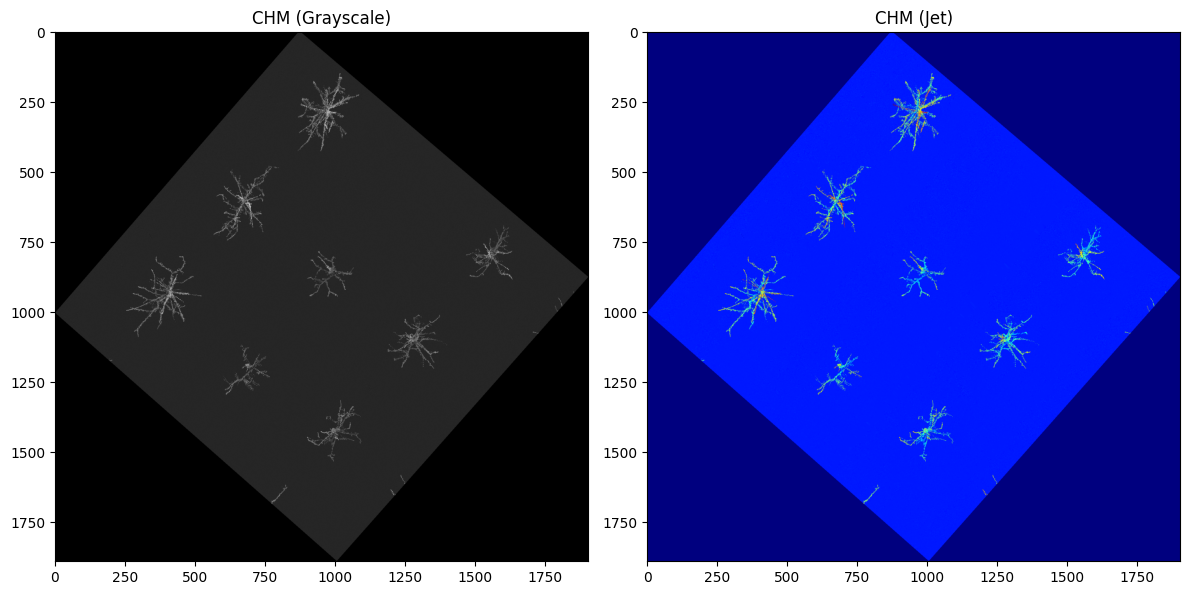

CPU times: user 4min 14s, sys: 4.25 s, total: 4min 18s
Wall time: 4min 30s


In [ ]:
%%time
import matplotlib.pyplot as plt
from skimage import io

polygon_path = write_roi_polygon(sub_points, f"{WORK}/patch_polygon.shp")
denoised_path, roi_las_name = denoising(LAS, polygon_path)
ground_path, above_path = ground_filtering(denoised_path, resolution=0.1, threshold=0.5)
chm_path = make_chm(ground_path, denoised_path, roi_las_name, polygon_path)
print("CHM:", chm_path)

img = io.imread(chm_path)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap=plt.cm.gray); axes[0].set_title('CHM (Grayscale)')
axes[1].imshow(img, cmap=plt.cm.jet);  axes[1].set_title('CHM (Jet)')
plt.tight_layout(); plt.show()

### Register the CHM to the RTK frame and detect individual trees

Applies the authors' `transform_chm` (perspective warp using the four patch-corner points) and `extract_bbox` (Otsu → closing → connected components). The displayed figure is the **binarized CHM with the detected red tree bounding boxes** — the segmentation input/annotation view of this run.

**樹木検出(日本語):** RTKフレームへCHMを補正し、赤枠で検出樹を表示します。

[(-2, 872), (1004, -1), (1891, 1006), (877, 1904)]
num_rows: 1354, num_cols: 1355
Transform: | 0.01,-0.01,-2185230.59|
|-0.01,-0.01, 13857645.32|
| 0.00, 0.00, 1.00|


CHM array shape: (1891, 1903)


detected trees: 9


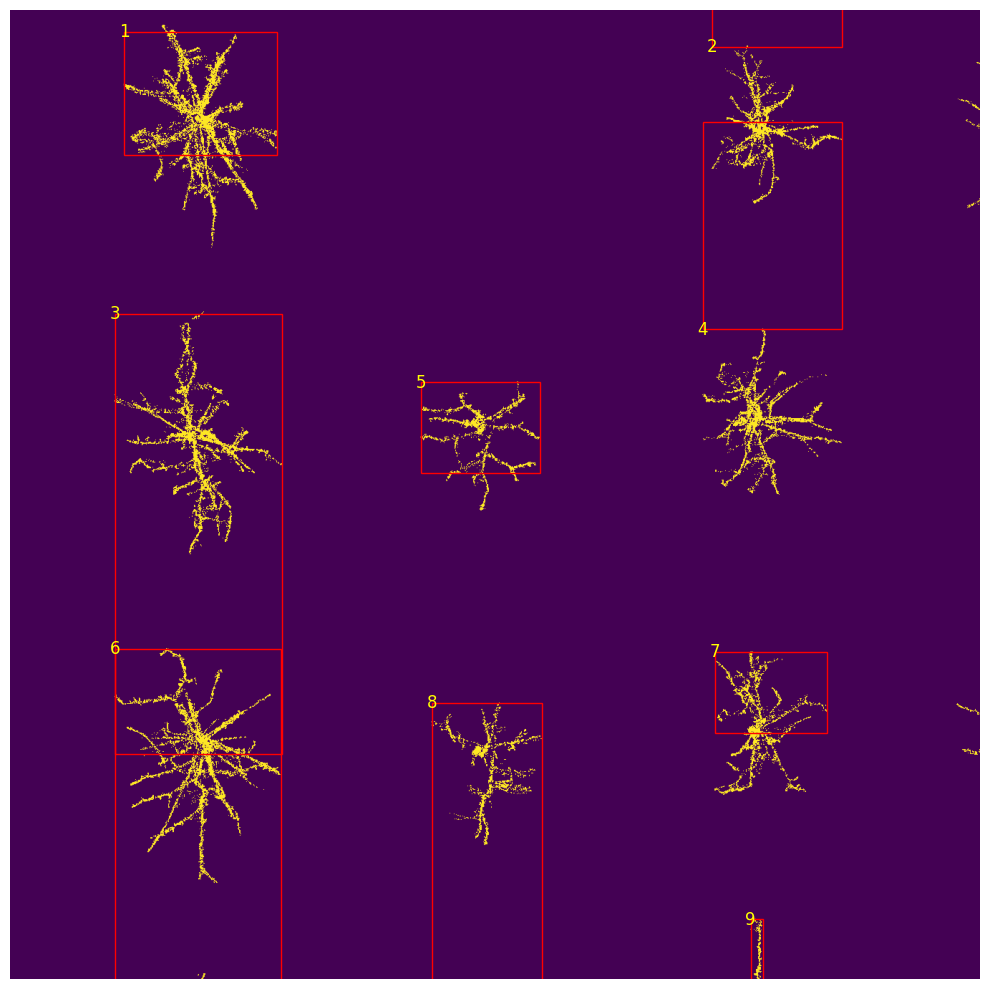

CPU times: user 1.26 s, sys: 255 ms, total: 1.52 s
Wall time: 1.62 s


In [ ]:
%%time
lidar_transformed_chm_path = transform_chm(chm_path, f"{WORK}/sub_roi_points.shp")
lidar_centroid_list, lidar_bbox_list, lidar_binary = extract_bbox(lidar_transformed_chm_path)
print(f"detected trees: {len(lidar_bbox_list)}")
plt.show()

### Clip single trees and denoise them

Generates one geographic polygon per detected tree, clips the patch cloud with WhiteboxTools, and runs the authors' per-tree kNN denoising (sigma=1, K=10).

**単木分割とノイズ除去(日本語):** 樹木ごとのポリゴンでクリップし、kNN距離デノイジングを適用します。

In [ ]:
%%time
lidar_shapefile_paths = generate_tree_shapefiles(lidar_bbox_list, lidar_transformed_chm_path)
print(f"{len(lidar_shapefile_paths)} polygon shapefiles written")

segment_single_tree(denoised_path, lidar_shapefile_paths)

# the authors' functions write next to the input LAS, i.e. under /content/oq3d/Data_pear
tree_dir = os.path.join(os.path.dirname(denoised_path), "Result_dir", "origin_single_tree_las")
lidar_denosied_tree_folder = os.path.join(os.path.dirname(denoised_path), "Result_dir", "denosied_single_tree_las")
denoise_pear_tree(tree_dir, lidar_denosied_tree_folder, sigma=1, K=10)
tree_files_all = sorted(os.listdir(lidar_denosied_tree_folder))
print("single trees:", tree_files_all)

9 polygon shapefiles written


denoised 4.las: kept 207630/232475 points


denoised 6.las: kept 259271/291837 points


denoised 1.las: kept 332207/372547 points


denoised 2.las: kept 661533/775422 points


...

denoised 7.las: kept 198998/224607 points


denoised 0.las: kept 633337/714027 points


denoised 5.las: kept 517869/581547 points


denoised 8.las: kept 7626/8943 points


single trees: ['0.las', '1.las', '2.las', '3.las', '4.las', '5.las', '6.las', '7.las', '8.las']
CPU times: user 2min 54s, sys: 333 ms, total: 2min 54s
Wall time: 3min 12s


### Select single trees and preview their point clouds

Deterministically selects up to the first two denoised single trees for skeletonization and traits. The 3D scatter previews show the **actual input clouds** used from here on, colored by height (dormancy LiDAR clouds carry no RGB; color is display-only).

**単木の選択とプレビュー(日本語):** 決定的に最大2木を選び、高さ着色の3D散布図で表示します。

selected trees: ['0.las', '1.las']


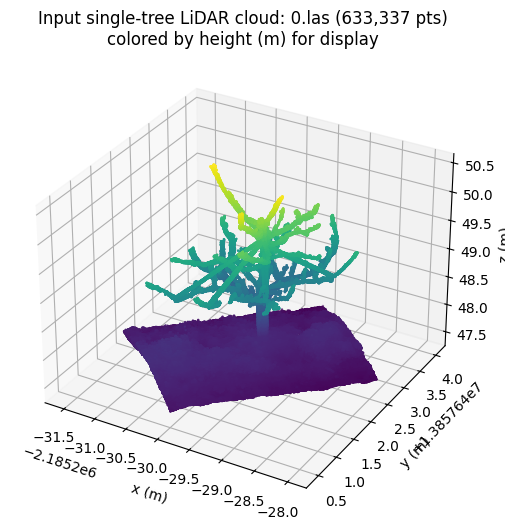

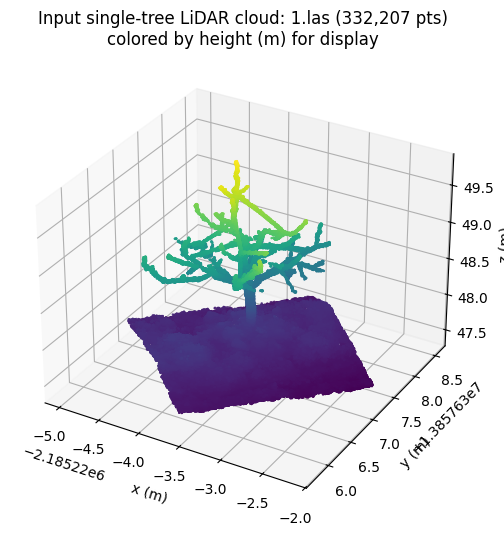

CPU times: user 27.3 s, sys: 137 ms, total: 27.4 s
Wall time: 27.2 s


In [ ]:
%%time
import matplotlib.pyplot as plt
import laspy, numpy as np

tree_files = tree_files_all[:2]
assert len(tree_files) >= 1, "no single trees were extracted"
print("selected trees:", tree_files)

tree_clouds = {}
for fn in tree_files:
    las = laspy.read(os.path.join(lidar_denosied_tree_folder, fn))
    pts = np.vstack([las.x, las.y, las.z]).T
    tree_clouds[fn] = pts
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(111, projection='3d')
    s = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=pts[:, 2], s=0.5, cmap='viridis')
    ax.set_title(f"Input single-tree LiDAR cloud: {fn} ({len(pts):,} pts)\ncolored by height (m) for display")
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
    plt.show()

### Extract 3D skeletons of the selected trees (SLBC)

Runs the authors' skeletonization per tree: trunk/branch separation (1 mm slices, radius 0.15 m — the authors' lidar value) then Semantic Laplacian-Based Contraction. This is the slowest step; progress is printed. Results are saved under `/content/oq3d/work/Result_dir/skeleton/` as in the authors' workflow.

**骨格抽出の実行(日本語):** 各単木にSLBC骨格抽出を実行します(数分/木)。

In [ ]:
%%time
import time, open3d as o3d, laspy, numpy as np, os

lidar_pcd_folder = f"{WORK}/Result_dir/pcd_subset"
skeleton_folder = f"{WORK}/Result_dir/skeleton"
create_folder_if_not_exists(lidar_pcd_folder)

for fn in tree_files:
    las = laspy.read(os.path.join(lidar_denosied_tree_folder, fn))
    x, y, z = las.x, las.y, las.z
    points = np.vstack((x - np.min(x), y - np.min(y), z - np.min(z))).transpose()
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    o3d.io.write_point_cloud(os.path.join(lidar_pcd_folder, fn[:-4] + ".pcd"), pcd, write_ascii=True)

skeletons = {}
for pcd_file in sorted(os.listdir(lidar_pcd_folder)):
    pcd_path = os.path.join(lidar_pcd_folder, pcd_file)
    pcd = o3d.io.read_point_cloud(pcd_path)
    t0 = time.time()
    try:
        trunk_pcd, branch_pcd = extract_trunk_points(pcd, 0.001, 0.15)  # author lidar radius
    except UnboundLocalError:
        trunk_pcd, branch_pcd = extract_trunk_points(pcd, 0.001, 0.5)   # author fallback
    trunk_folder = os.path.join(skeleton_folder, "trunk", pcd_file[:-4])
    create_folder_if_not_exists(trunk_folder)
    o3d.io.write_point_cloud(os.path.join(trunk_folder, "trunk_" + pcd_file), trunk_pcd)
    slbc = extract_skeleton(trunk_pcd, branch_pcd, semantic_weighting=5, down_sample=0.01)
    slbc.save(os.path.join(skeleton_folder, "mesh", pcd_file[:-4]))
    skeletons[pcd_file[:-4]] = slbc
    print(f"{pcd_file}: skeleton {len(slbc.skeleton.points)} pts in {time.time()-t0:.0f}s", flush=True)

pcd_trunk PointCloud with 1301 points.
pcd_branch PointCloud with 632036 points.


  0%|          | 0/20 [00:00<?, ?it/s]

Current volume ratio 1.0. Contraction weights 11.5379726376857. Attraction weights 0.5. Progress SLBC:   0%|          | 0/20 [00:00<?, ?it/s]

Current volume ratio 1.0. Contraction weights 11.5379726376857. Attraction weights 0.5. Progress SLBC:   5%|▌         | 1/20 [01:29<28:25, 89.78s/it]

Current volume ratio 1.0. Contraction weights 57.689863188428504. Attraction weights 0.5. Progress SLBC:   5%|▌         | 1/20 [01:44<28:25, 89.78s/it]

...

Current volume ratio 0.0078026360068095555. Contraction weights 2048.0. Attraction weights 1019.9688862988257. Progress SLBC: 100%|██████████| 20/20 [04:49<00:00, 12.21s/it]

Contraction is Done.


Current volume ratio 0.0078026360068095555. Contraction weights 2048.0. Attraction weights 1019.9688862988257. Progress SLBC: 100%|██████████| 20/20 [04:58<00:00, 14.94s/it]

1.pcd: skeleton 8863 pts in 308s


CPU times: user 15min 17s, sys: 41.2 s, total: 15min 58s
Wall time: 16min


### Trait table for the selected trees

Computes the four canopy traits per selected tree from the denoised clouds and shows a small table; a CSV copy is written next to the results. All units are metric (m, m², m³) because the RTK-tagged clouds are metric.

**形質テーブル(日本語):** 最大樹高・凸包表面積・体積・投影面積を表とCSVに出力します。

In [ ]:
%%time
import pandas as pd, open3d as o3d, numpy as np, os

mesh_file = f"{WORK}/Result_dir/mesh"
create_folder_if_not_exists(mesh_file)

rows = []
for i, fn in enumerate(tree_files):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(tree_clouds[fn] - tree_clouds[fn].min(axis=0))
    height = calculate_height(pcd)
    area, volume = calculate_surfacearea_and_volumn(pcd, mesh_file, i)
    proj_area = out_2d_area(pcd)
    rows.append({"tree": fn, "HeightMax (m)": round(height, 3),
                 "ConvexHull SurfaceArea (m2)": round(area, 3),
                 "ConvexHull Volume (m3)": round(volume, 3),
                 "Projected Area XY (m2)": round(proj_area, 3)})
traits_df = pd.DataFrame(rows)
csv_path = f"{WORK}/Result_dir/traits_selected_trees.csv"
traits_df.to_csv(csv_path, index=False)
print(f"saved {csv_path}")
traits_df

saved /content/oq3d/work/Result_dir/traits_selected_trees.csv
CPU times: user 1.27 s, sys: 67.6 ms, total: 1.34 s
Wall time: 1.49 s


,tree,HeightMax (m),ConvexHull SurfaceArea (m2),ConvexHull Volume (m3),Projected Area XY (m2)
0,0.las,2.98,30.532,12.563,6.353
1,1.las,2.31,18.192,5.810,3.966


### Skeleton visualization

Renders each selected tree as its input point cloud (gray, height-shaded) with the SLBC skeleton points and topology lines (red) overlaid — the core qualitative result, rendered in Colab from the actual run outputs.

**骨格の可視化(日本語):** 入力点群(灰)にSLBC骨格(赤)を重ねて表示します。

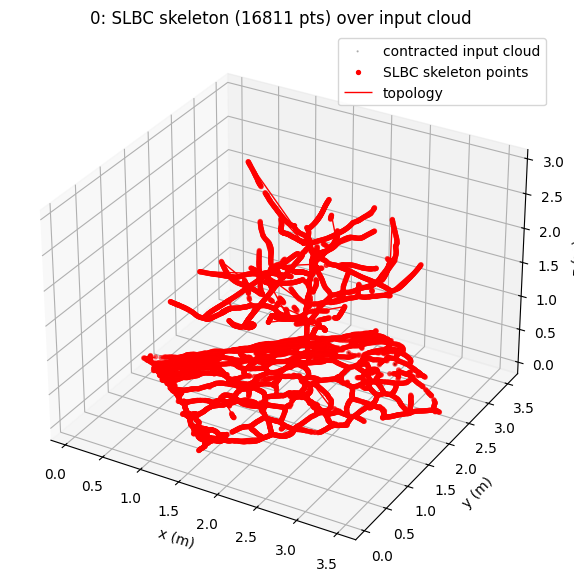

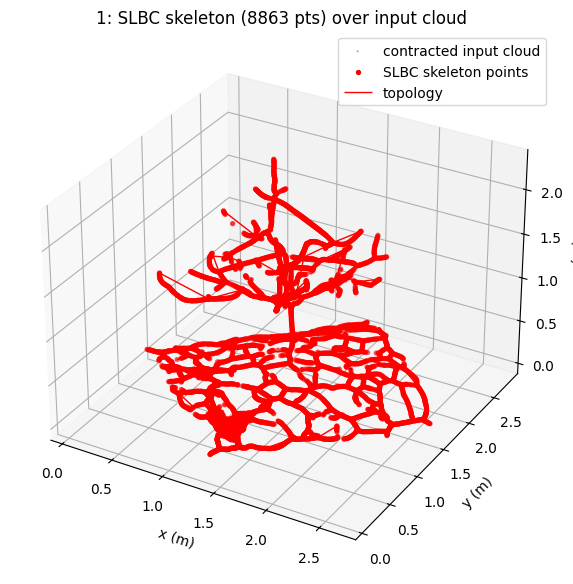

CPU times: user 9.91 s, sys: 94.4 ms, total: 10 s
Wall time: 9.64 s


In [ ]:
%%time
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection

for name, slbc in skeletons.items():
    pts = np.asarray(slbc.contracted_point_cloud.points) if hasattr(slbc, 'contracted_point_cloud') else None
    skel = np.asarray(slbc.skeleton.points)
    topo_pts = np.asarray(slbc.topology.points)
    topo_lines = np.asarray(slbc.topology.lines)
    fig = plt.figure(figsize=(7, 9))
    ax = fig.add_subplot(111, projection='3d')
    if pts is not None and len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3, c=pts[:, 2], cmap='gray', alpha=0.3,
                   label='contracted input cloud')
    ax.scatter(skel[:, 0], skel[:, 1], skel[:, 2], s=8, c='red', label='SLBC skeleton points')
    segs = [[topo_pts[a], topo_pts[b]] for a, b in topo_lines]
    ax.add_collection3d(Line3DCollection(segs, colors='red', linewidths=1.0, label='topology'))
    ax.set_title(f"{name}: SLBC skeleton ({len(skel)} pts) over input cloud")
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
    ax.legend()
    plt.show()

## Interpretation and limitations

- The executed demonstration reproduces the **LiDAR dormancy branch** of OrchardQuant-3D end-to-end on the authors' pear test data — ROI clipping, chunked SOR denoising, CSF ground filtering, CHM generation (WhiteboxTools TIN gridding, 0.01 m), RTK CHM registration, automatic tree detection, single-tree clipping, per-tree denoising, SLBC skeletonization and tree-level traits (`HeightMax`, convex-hull surface area/volume, projected XY area) — all in metric units.
- **Adapted scope:** the chain runs on a deterministic sub-orchard patch instead of the full 70-tree orchard (the released `dormancy_pear.las` is 4.5 GB, beyond free-Colab memory). All functions and parameters are the authors', copied verbatim from release V1.2 commit `4d4062e754a9807e765bf82fc4350d0676f2c671`.
- **Dependency substitutions (recorded):** `mistree==2.0.0` (pure-Python; the author-cited 1.2.0 sdist cannot build on Python 3.13) and `cloth_simulation_filter` 1.1.7 for CSF ground filtering (the official jianboqi/CSF binding; author cites 1.1.5 — same `CSF` API).
- A patch-level, 2-tree run **does not** verify the paper's dataset-level results (70-tree trait tables, validation against manual scoring/TreeQSM) nor any UAV-fusion, floral, or apple/fruit-detection results.
- Provenance: paper PMC12576445 (CC BY); code BSD-3-Clause; data from release V1.2 (`Data_pear.zip` sha256 `355c1064…`, `RTK_shapefiles.zip` sha256 `055de4f4…` — full hashes in the download cell output).

**結果の解釈と限界(日本語):** 本ノートブックは著者提供データを用いてLiDAR休眠期処理系(CHM生成・樹木検出・単木分割・骨格抽出・形質算出)を端から端まで再現するものですが、処理範囲は果樹園の一部分です。論文のデータセット全体の精度検証やUAV融合・花・果実解析の再現ではありません。